In [8]:
# ------------------------------------------------------------------------------
# Suppress Warnings
# ------------------------------------------------------------------------------
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# Data Science Libraries
# ------------------------------------------------------------------------------
import numpy as np
import pandas as pd
import xarray as xr  # Multi-dimensional arrays and datasets

# ------------------------------------------------------------------------------
# Geospatial Data Handling
# ------------------------------------------------------------------------------
import rioxarray as rxr          # Geospatial raster data handling
import geopandas as gpd          # Geospatial data analysis

# Raster operations with rasterio
import rasterio
from rasterio import windows, features, warp
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds

# ------------------------------------------------------------------------------
# Visualization
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------------------
# Image Processing
# ------------------------------------------------------------------------------
from PIL import Image

# ------------------------------------------------------------------------------
# Coordinate Transformations
# ------------------------------------------------------------------------------
from pyproj import Proj, Transformer, CRS

# ------------------------------------------------------------------------------
# Feature Engineering & Model Selection
# ------------------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, GridSearchCV

# ------------------------------------------------------------------------------
# Machine Learning & Metrics
# ------------------------------------------------------------------------------
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

# ------------------------------------------------------------------------------
# Gaussian Process Regression
# ------------------------------------------------------------------------------
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

# ------------------------------------------------------------------------------
# Planetary Computer Tools
# ------------------------------------------------------------------------------
import pystac_client
import planetary_computer as pc
from pystac.extensions.eo import EOExtension as eo

# ------------------------------------------------------------------------------
# Other Utilities
# ------------------------------------------------------------------------------
import os
from tqdm import tqdm
import xml.etree.ElementTree as ET
from shapely.geometry import Polygon, Point
import ast

##

import xgboost as xgb
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [4]:
saved_train_data = pd.read_csv('saved_train_data.csv')
saved_train_data.head()

,airtemp,relative humidity,avg wind speed,wind direction,solar flux,building_area_25,building_area_50,building_area_100,B01,B02,...,B8A,B11,B12,Weather Normalized Site EUI (kBtu/ft²),Weather Normalized Site Energy Use (kBtu),Electricity Use - Grid Purchase (kWh),Natural Gas Use (kBtu),ENERGY STAR Score,Area_Manhattan,UHI Index
0,-1.142219,0.683841,0.578307,0.814269,-1.531980,1.456394,1.057720,0.898824,0.738705,3.492417,...,0.956565,1.990267,1.847867,0.245099,-0.294237,-0.151568,-0.225578,0.209808,True,1.011056
1,-0.510366,0.683841,-0.182716,0.238885,-0.463903,1.945507,0.783492,-0.193245,0.528477,-0.107615,...,0.062987,1.416564,1.521532,0.656428,-0.081910,-0.164657,0.122308,-0.210480,False,0.992424
2,0.332104,-0.364639,1.034921,1.389653,-0.587575,0.796822,0.633919,0.423201,-0.675178,0.354701,...,-0.704919,-0.364516,-0.228498,-0.189672,0.107281,0.100325,-0.021152,1.023872,True,0.971147
3,2.017044,-2.244672,-2.161376,-2.126582,0.587310,0.195098,0.126531,-0.712112,-0.190143,0.123543,...,-0.223894,-0.050678,0.140479,-0.190757,-0.341121,-0.189861,-0.266080,-0.034646,False,1.024880
4,-0.720984,0.105369,0.426102,1.197858,0.851519,-0.167564,0.463721,1.249540,2.608768,1.600943,...,-0.463106,0.503036,0.826219,0.729873,-0.208801,-0.008779,-0.235162,-0.145761,True,1.024279


In [6]:
X_train = saved_train_data.iloc[:,:-1]
X_train.head()

,airtemp,relative humidity,avg wind speed,wind direction,solar flux,building_area_25,building_area_50,building_area_100,B01,B02,...,B08,B8A,B11,B12,Weather Normalized Site EUI (kBtu/ft²),Weather Normalized Site Energy Use (kBtu),Electricity Use - Grid Purchase (kWh),Natural Gas Use (kBtu),ENERGY STAR Score,Area_Manhattan
0,-1.142219,0.683841,0.578307,0.814269,-1.531980,1.456394,1.057720,0.898824,0.738705,3.492417,...,2.457983,0.956565,1.990267,1.847867,0.245099,-0.294237,-0.151568,-0.225578,0.209808,True
1,-0.510366,0.683841,-0.182716,0.238885,-0.463903,1.945507,0.783492,-0.193245,0.528477,-0.107615,...,-0.642406,0.062987,1.416564,1.521532,0.656428,-0.081910,-0.164657,0.122308,-0.210480,False
2,0.332104,-0.364639,1.034921,1.389653,-0.587575,0.796822,0.633919,0.423201,-0.675178,0.354701,...,-1.011423,-0.704919,-0.364516,-0.228498,-0.189672,0.107281,0.100325,-0.021152,1.023872,True
3,2.017044,-2.244672,-2.161376,-2.126582,0.587310,0.195098,0.126531,-0.712112,-0.190143,0.123543,...,-0.864783,-0.223894,-0.050678,0.140479,-0.190757,-0.341121,-0.189861,-0.266080,-0.034646,False
4,-0.720984,0.105369,0.426102,1.197858,0.851519,-0.167564,0.463721,1.249540,2.608768,1.600943,...,0.132691,-0.463106,0.503036,0.826219,0.729873,-0.208801,-0.008779,-0.235162,-0.145761,True


In [7]:
y_train = saved_train_data.iloc[:,-1]
y_train.head()

0    1.011056
1    0.992424
2    0.971147
3    1.024880
4    1.024279
Name: UHI Index, dtype: float64

# Question 1: How can we best use these factors to predict the UHI Index in the Manhattan and Bronx areas?

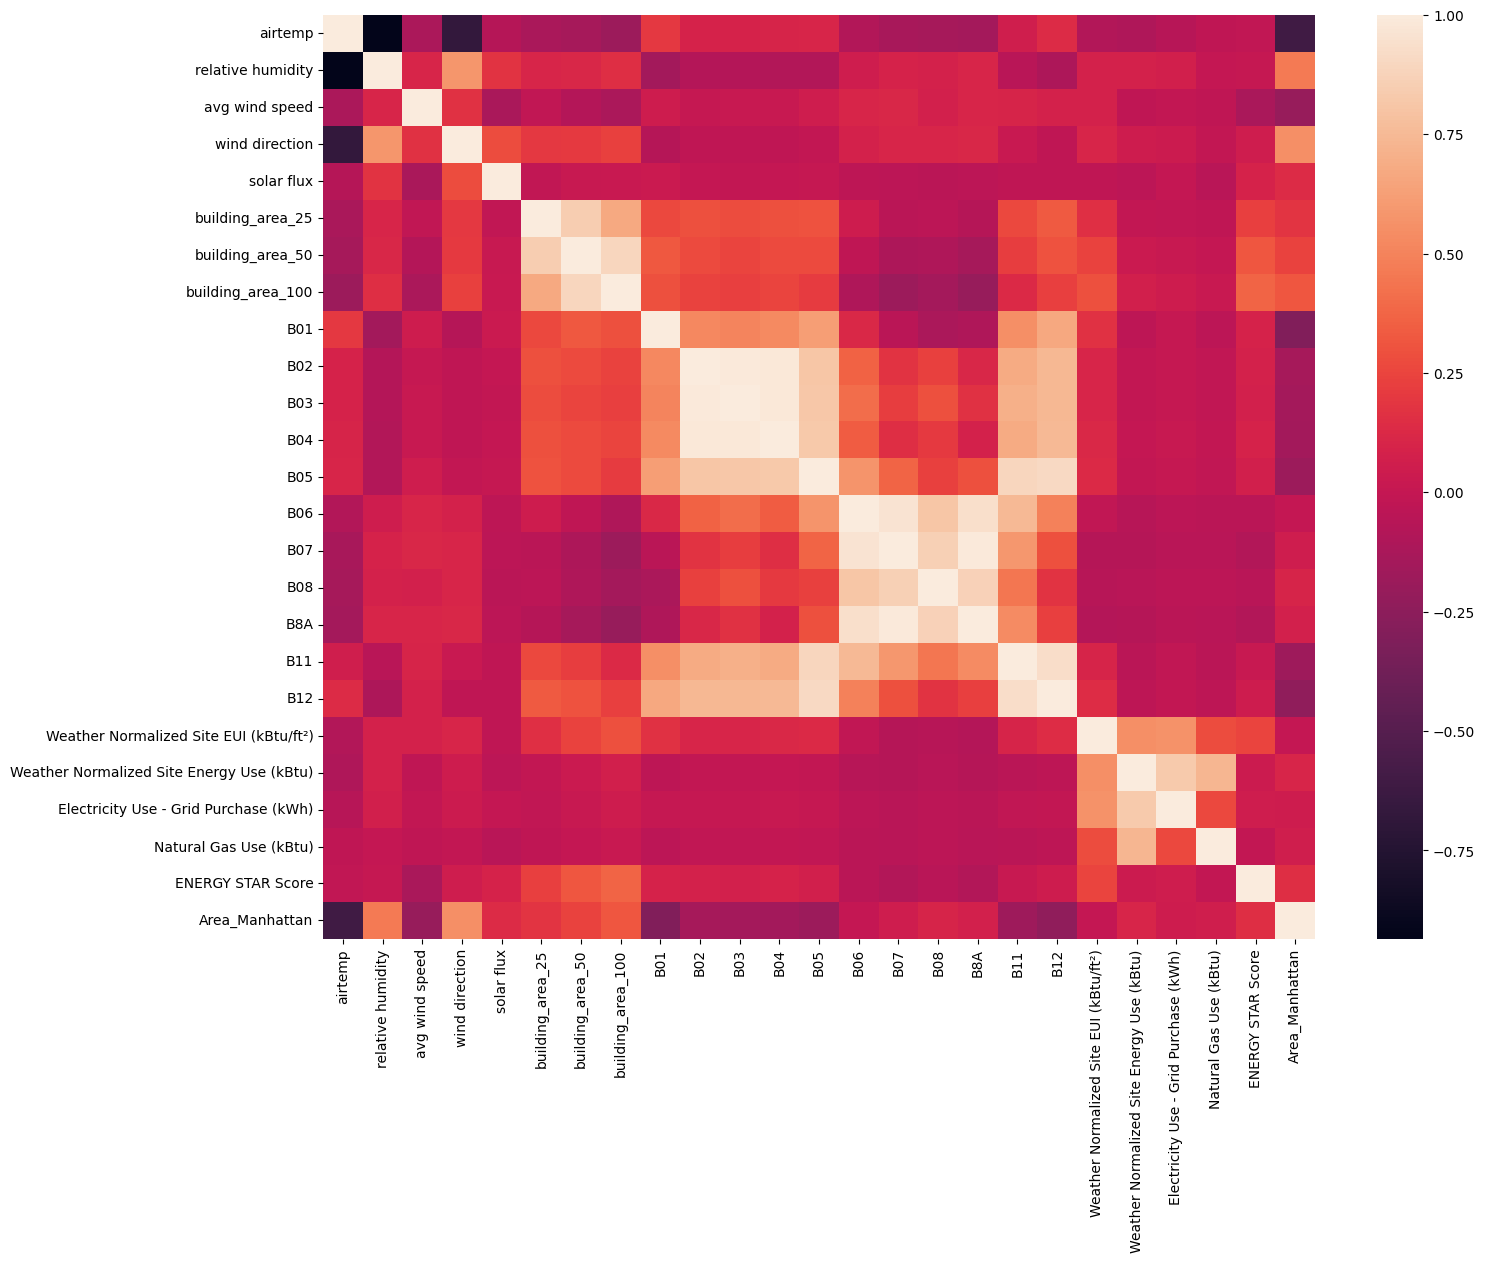

In [124]:
plt.figure(figsize=(16, 12))  # Adjust width and height as needed
sns.heatmap(X_train.corr())
plt.show()

# XGBoost

In [102]:
param_grid = {
    'n_estimators': [500,1000,2000],
    'eta': [0.1,0.05],
    'max_depth': [6,10,14],
    'subsample': [0.8,1]
}


booster = xgb.XGBRegressor(objective='reg:squarederror', random_state=123)

kf = KFold(n_splits=4, shuffle=True, random_state=123)

xgb_grid_search = GridSearchCV(estimator=booster, param_grid=param_grid, cv=kf, n_jobs=-1, scoring='r2',verbose=1)

xgb_grid_search.fit(X_train, y_train)


print("Best Hyperparameters:", xgb_grid_search.best_params_)
print("Best R^2 (Mean Test Score)", xgb_grid_search.best_score_)

Fitting 4 folds for each of 36 candidates, totalling 144 fits
Best Hyperparameters: {'eta': 0.05, 'max_depth': 10, 'n_estimators': 2000, 'subsample': 0.8}
Best R^2 (Mean Test Score) 0.9224338844071129


# Linear Regression

In [83]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

def calculate_mallows_cp(X, y, sigma2_full):
    """
    Fit a linear regression model on X and y and compute Mallows Cp.
    Cp = RSS/sigma2_full - n + 2*(p+1)
    where n is the number of observations and p is the number of predictors.
    """
    n = len(y)
    model = LinearRegression().fit(X, y)
    predictions = model.predict(X)
    RSS = np.sum((y - predictions) ** 2)
    p = X.shape[1]  # number of predictors
    cp = RSS / sigma2_full - n + 2 * (p + 1)  # +1 accounts for the intercept
    return cp, RSS

def backward_selection_mallows_cp(X, y):
    """
    Performs backward elimination based on Mallows Cp.
    Starts with all features and iteratively removes the feature that leads to
    the lowest Mallows Cp until no removal further decreases Cp.
    """
    n = len(y)
    features = list(X.columns)
    
    # Fit full model and estimate sigma^2 using the unbiased estimator.
    full_model = LinearRegression().fit(X, y)
    predictions_full = full_model.predict(X)
    RSS_full = np.sum((y - predictions_full) ** 2)
    p_full = X.shape[1]
    sigma2_full = RSS_full / (n - (p_full + 1))
    print("Estimated sigma^2 from full model:", sigma2_full)
    
    # Initialize with all features.
    current_features = features.copy()
    current_cp, _ = calculate_mallows_cp(X[current_features], y, sigma2_full)
    print("Initial Mallows Cp with all features:", current_cp)
    
    improvement = True
    while improvement and len(current_features) > 1:
        cp_candidates = []
        # Try removing each feature one at a time.
        for feature in current_features:
            candidate_features = [f for f in current_features if f != feature]
            cp, _ = calculate_mallows_cp(X[candidate_features], y, sigma2_full)
            cp_candidates.append((cp, feature))
        
        # Select the candidate whose removal gives the lowest Cp.
        cp_candidates.sort(key=lambda x: x[0])
        best_candidate_cp, feature_to_remove = cp_candidates[0]
        
        # If removal improves (i.e. lowers) Cp, then remove the feature.
        if best_candidate_cp < current_cp:
            current_features.remove(feature_to_remove)
            current_cp = best_candidate_cp
            print(f"Removed '{feature_to_remove}', new Mallows Cp = {current_cp:.4f}")
        else:
            improvement = False

    return current_features, current_cp

# --- Feature Selection using Backward Elimination with Mallows Cp ---
# Assume X_train is a pandas DataFrame and y_train is a Series or numpy array.
selected_features, final_cp = backward_selection_mallows_cp(X_train, y_train)
print("\nSelected features:", selected_features)
print("Final Mallows Cp:", final_cp)

# --- Cross-Validation to Estimate Test R^2 on the Final Model ---
model = LinearRegression()
cv_scores = cross_val_score(model, X_train[selected_features], y_train, cv=5, scoring='r2')
print("\nCross-validated R^2 scores:", cv_scores)c
print("Mean cross-validated R^2:", np.mean(cv_scores))


Estimated sigma^2 from full model: 0.00018849712176073304
Initial Mallows Cp with all features: 26.0
Removed 'B07', new Mallows Cp = 24.2881
Removed 'avg wind speed', new Mallows Cp = 22.8084
Removed 'B06', new Mallows Cp = 21.5074
Removed 'Weather Normalized Site Energy Use (kBtu)', new Mallows Cp = 20.3250

Selected features: ['airtemp', 'relative humidity', 'wind direction', 'solar flux', 'building_area_25', 'building_area_50', 'building_area_100', 'B01', 'B02', 'B03', 'B04', 'B05', 'B08', 'B8A', 'B11', 'B12', 'Weather Normalized Site EUI (kBtu/ft²)', 'Electricity Use - Grid Purchase (kWh)', 'Natural Gas Use (kBtu)', 'ENERGY STAR Score', 'Area_Manhattan']
Final Mallows Cp: 20.325035708532596

Cross-validated R^2 scores: [0.28620602 0.26917704 0.29141521 0.27306945 0.30005096]
Mean cross-validated R^2: 0.28398373697724166


# Lasso Regression

In [91]:
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score 
from sklearn.linear_model import Lasso

# 0.0001 to 1 in 50 points and 1 to 1000 in 50 points
alphas = np.concatenate((np.logspace(-4,0,50), np.linspace(1,1000,50)))

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)

lasso_cv.fit(X_train, y_train)


best_alpha_cv = lasso_cv.alpha_

print("Best alpha from LassoCV:", best_alpha_cv)
print("Best coefs from LassoCV:", lasso_cv.coef_)

final_lasso = Lasso(alpha = best_alpha_cv)

cv = cross_validate(final_lasso,X_train,y_train,scoring=['r2','neg_mean_squared_error'],return_train_score=True,cv=5)
print("Mean cross-validated R^2:", np.mean(cv['test_r2']))

Best alpha from LassoCV: 0.0001
Best coefs from LassoCV: [-4.56616247e-03 -3.63785662e-03  1.40925111e-04 -8.50525956e-04
  1.45587356e-03 -9.67214459e-04  0.00000000e+00  1.22922030e-03
  2.81700236e-03  0.00000000e+00  7.60104527e-04  0.00000000e+00
  0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -4.78977662e-04
 -0.00000000e+00 -1.42373332e-03  0.00000000e+00  1.46311553e-03
 -1.99026306e-05 -7.32017842e-04 -2.08715802e-04  5.66242030e-04
 -1.47376459e-02]
Mean cross-validated R^2: 0.27630804997827696


# ElasticNet

In [92]:
from sklearn.linear_model import ElasticNetCV

alphas = np.logspace(-4, 2, 400)        
l1_ratios = np.linspace(0.001,0.5,50)           

# Initialize ElasticNetCV with 5-fold cross-validation
elastic_net_cv = ElasticNetCV(alphas=alphas, l1_ratio=l1_ratios, cv=5, max_iter=10000)

# Fit the model on training data
elastic_net_cv.fit(X_train, y_train)

# Retrieve the best hyperparameters
best_alpha = elastic_net_cv.alpha_
best_l1_ratio = elastic_net_cv.l1_ratio_

print("Best alpha:", best_alpha)
print("Best l1_ratio:", best_l1_ratio)

Best alpha: 0.00022175052752539318
Best l1_ratio: 0.001


I tested multiple values for L1 ratio but it seems like it would be better off if L1 ratio was 0, so I'll move onto a ridge regression.

# Ridge

After first run, the best alpha value is 100. Changed the range multiple times to find optimal alpha.

In [95]:
from sklearn.linear_model import RidgeCV, Ridge

# 0.0001 to 1 in 50 points and 1 to 1000 in 50 points
alphas = np.logspace(0,3,1000)

ridge_cv = RidgeCV(alphas=alphas, scoring='r2', cv=4)

# Fit RidgeCV on your training data
ridge_cv.fit(X_train, y_train)

# The best alpha selected via cross-validation
best_alpha = ridge_cv.alpha_
print("Best alpha selected by RidgeCV:", best_alpha)
print("Best scored:", ridge_cv.best_score_)

Best alpha selected by RidgeCV: 3.108082173869064
Best scored: 0.28351377193879623


# RandomForest

In [98]:
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [2000],        
    'max_features': [24],
    'max_depth': [None]
}


rf = RandomForestRegressor(random_state=123)


grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',    
    n_jobs=-1,  
    verbose=1
)

# Fit GridSearchCV on your training data
grid_search.fit(X_train, y_train)

# Retrieve the best estimator, parameters, and score
best_rf = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best parameters:", best_params)
print("Best cross-validated R² score:", best_score)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters: {'max_depth': None, 'max_features': 24, 'n_estimators': 2000}
Best cross-validated R² score: 0.9157906189121936


# KNN

In [132]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
import numpy as np


param_grid = {'n_neighbors': range(1, 51),
             'weights': ['unifrom','distance']}
knn = KNeighborsRegressor()


grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)


grid_search.fit(X_train, y_train)


print("Best number of neighbors:", grid_search.best_params_)
print("Best cross-validated R^2:", grid_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best number of neighbors: {'n_neighbors': 3, 'weights': 'distance'}
Best cross-validated R^2: 0.8256799302225655


# Prediction

In [108]:
saved_val_data = pd.read_csv('saved_val_data.csv')

In [109]:
X_val = saved_val_data.drop(columns=['Longitude', 'Latitude'])

In [110]:
final_pred = xgb_grid_search.best_estimator_.predict(X_val)

In [111]:
submission_df = pd.DataFrame({'Longitude':saved_val_data['Longitude'].values, 
                              'Latitude':saved_val_data['Latitude'].values, 
                              'UHI Index':final_pred})

In [112]:
submission_df

,Longitude,Latitude,UHI Index
0,-73.960103,40.758877,0.973055
1,-73.960158,40.758905,0.973964
2,-73.960498,40.759058,0.976248
3,-73.959490,40.759067,0.972880
4,-73.960687,40.759162,0.982512
...,...,...,...
1035,-73.929665,40.857480,1.014801
1036,-73.931057,40.857525,1.032119
1037,-73.931460,40.858773,1.007294
1038,-73.931367,40.858937,1.017216


In [113]:
submission_df.to_csv('final_sub.csv')

# Question #2: Which urban and environmental factors most significantly influence the UHI index?

In [133]:
best_xgb = xgb_grid_search.best_estimator_

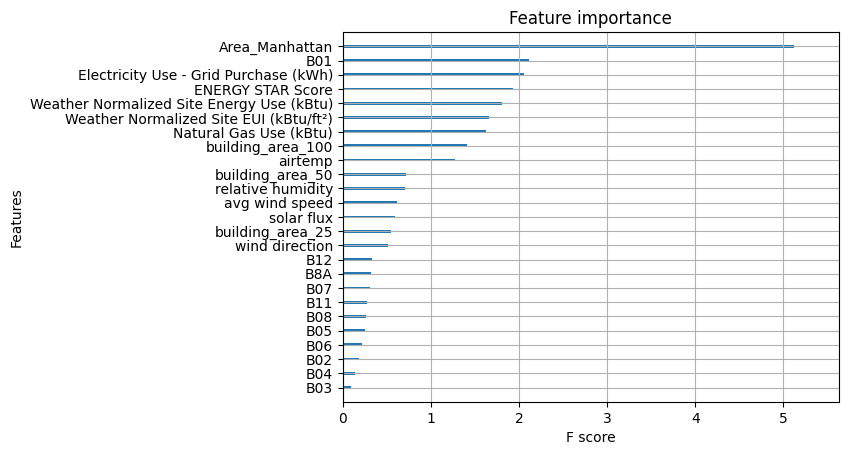

In [137]:
importances = best_xgb.feature_importances_

xgb.plot_importance(best_xgb,importance_type="total_gain", show_values=False)
plt.show()

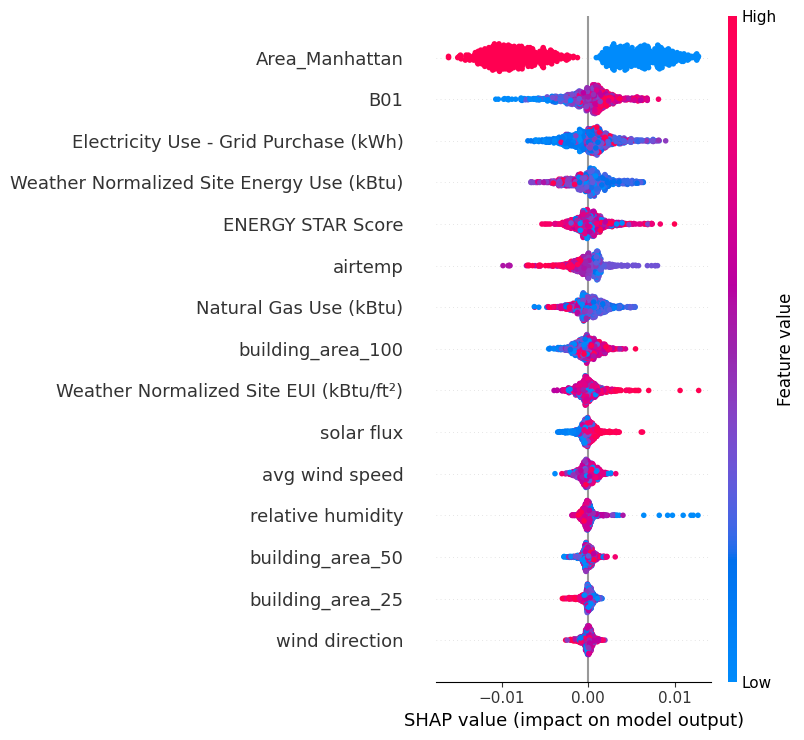

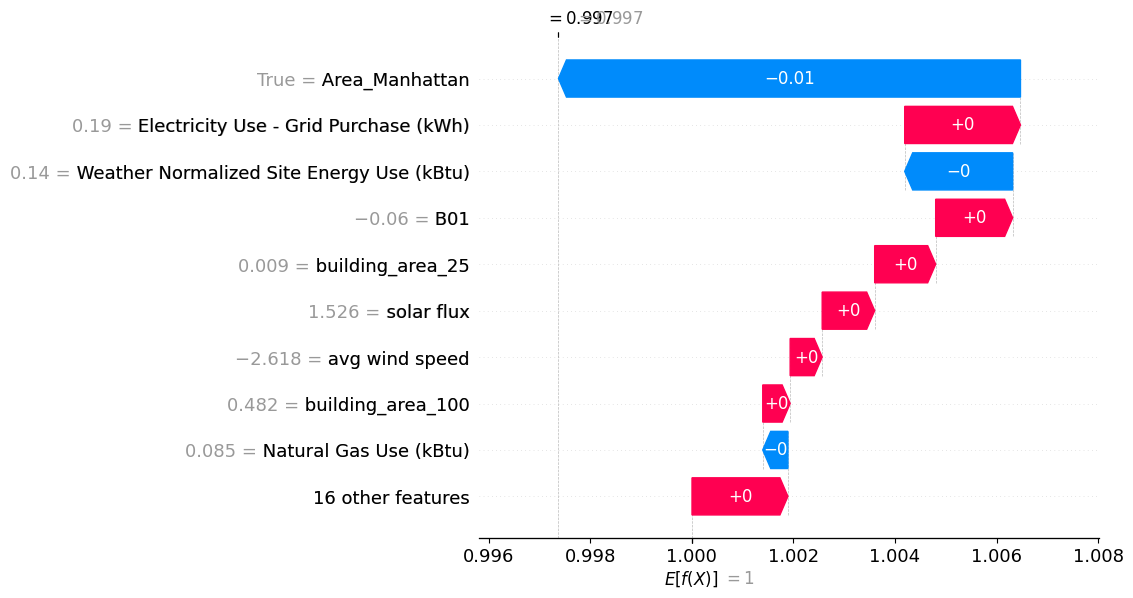

In [166]:
import shap
import matplotlib.pyplot as plt

X_sample = X_train.sample(n=1000, random_state=42)

explainer = shap.TreeExplainer(best_xgb)


shap_values = explainer.shap_values(X_sample)


shap.initjs()


shap.summary_plot(shap_values, X_sample, plot_type="dot", show=True, max_display=15)


instance = X_sample.iloc[3]

shap_explanation = shap.Explanation(values=shap_values[3],
                                    base_values=explainer.expected_value,
                                    data=instance,
                                    feature_names=X_sample.columns)
shap.plots.waterfall(shap_explanation, show=True)


plt.show()


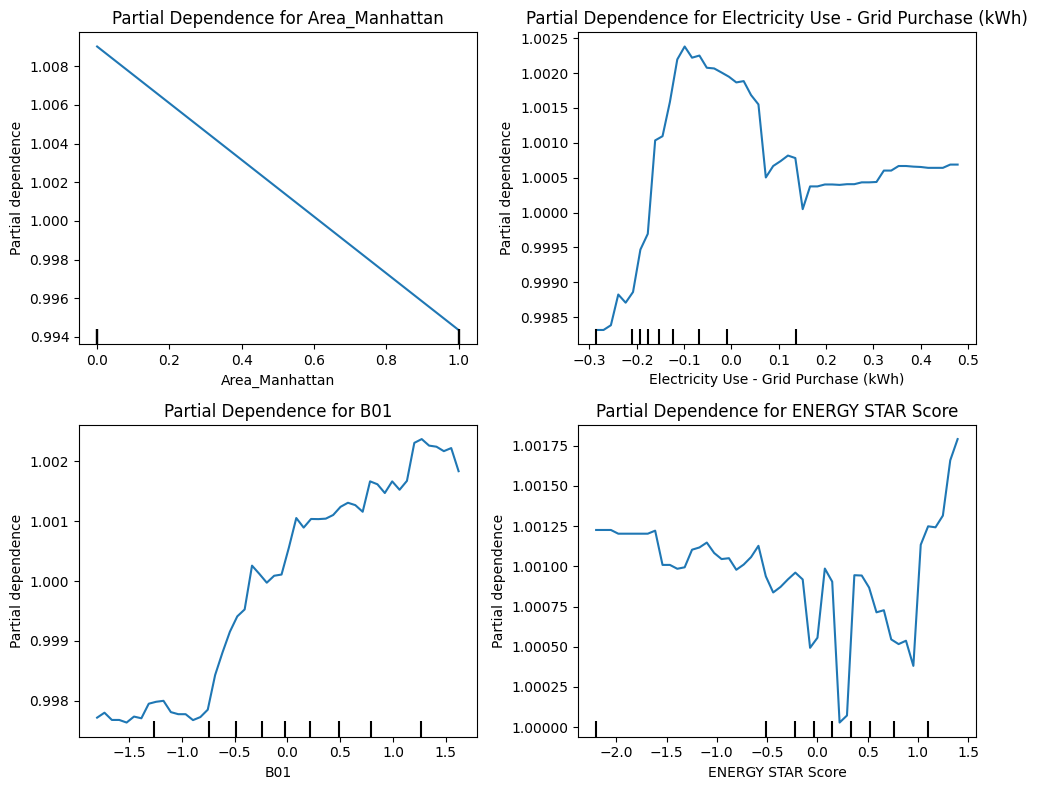

In [178]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# Define your list of 4 features
features = ['Area_Manhattan', 
            'Electricity Use - Grid Purchase (kWh)',
            'B01',
            'ENERGY STAR Score']

# Create a 2x2 subplot figure
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = axs.flatten()  # Flatten to iterate easily over the axes

# Loop over each feature and plot its partial dependence
for i, feature in enumerate(features):
    PartialDependenceDisplay.from_estimator(
        best_xgb,         # Your best XGBoost model
        X_train,          # Training data
        [feature],        # Feature to plot (as a list)
        kind="average",   # Average effect
        grid_resolution=50,  # Resolution of the plot grid
        ax=axs[i]         # Axis for the subplot
    )
    axs[i].set_title(f"Partial Dependence for {feature}")

plt.tight_layout()
plt.show()


# Question 3: How might UHI change if urban building density and environmental consumption were to increase? 

In [182]:
merged_df = pd.read_csv('save_train_data_unscaled.csv')

In [187]:
merged_df.columns

Index(['Longitude', 'Latitude', 'datetime', 'UHI Index', 'Area', 'airtemp',
       'relative humidity', 'avg wind speed', 'wind direction', 'solar flux',
       'building_area_25', 'building_area_50', 'building_area_100', 'B01',
       'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12',
       'Weather Normalized Site EUI (kBtu/ft²)',
       'Weather Normalized Site Energy Use (kBtu)',
       'Electricity Use - Grid Purchase (kWh)', 'Natural Gas Use (kBtu)',
       'ENERGY STAR Score'],
      dtype='object')

In [184]:
X_train = merged_df.drop(columns=['Longitude', 'Latitude', 'datetime', 'UHI Index'])
# One-hot encode the categorical 'Area' column (drop_first avoids dummy variable trap)
X_train = pd.get_dummies(X_train, columns=['Area'], drop_first=True)

# Identify numeric feature columns (exclude boolean columns)
input_features = X_train.select_dtypes(exclude=['boolean']).columns

# Initialize and fit the scaler on training numeric features
scaler = StandardScaler()
X_train[input_features] = scaler.fit_transform(X_train[input_features])

# Define the target variable
y_train = merged_df['UHI Index']

Apply simulation changes then use original scaler

In [185]:
simulation_df = merged_df.copy()

In [189]:
simulation_df = merged_df.copy()

density_cols = ['building_area_25', 'building_area_50', 'building_area_100']

consumption_cols = ['Weather Normalized Site EUI (kBtu/ft²)',
       'Weather Normalized Site Energy Use (kBtu)',
       'Electricity Use - Grid Purchase (kWh)', 'Natural Gas Use (kBtu)'] 

efficiency_col = 'ENERGY STAR Score'

simulation_df[density_cols] = simulation_df[density_cols] * 1.3

simulation_df[consumption_cols] = simulation_df[consumption_cols] * 1.3

simulation_df[efficiency_col] = simulation_df[efficiency_col] - 0.3

In [191]:
X_sim = simulation_df.drop(columns=['Longitude', 'Latitude', 'datetime', 'UHI Index'])

X_sim = pd.get_dummies(X_sim, columns=['Area'], drop_first=True)


input_features = X_sim.select_dtypes(exclude=['boolean']).columns


X_sim[input_features] = scaler.transform(X_sim[input_features])

In [193]:
sim_preds = best_xgb.predict(X_sim)
reg_preds = best_xgb.predict(X_train)

In [202]:
np.mean(sim_preds - reg_preds)

np.float32(0.0013811414)

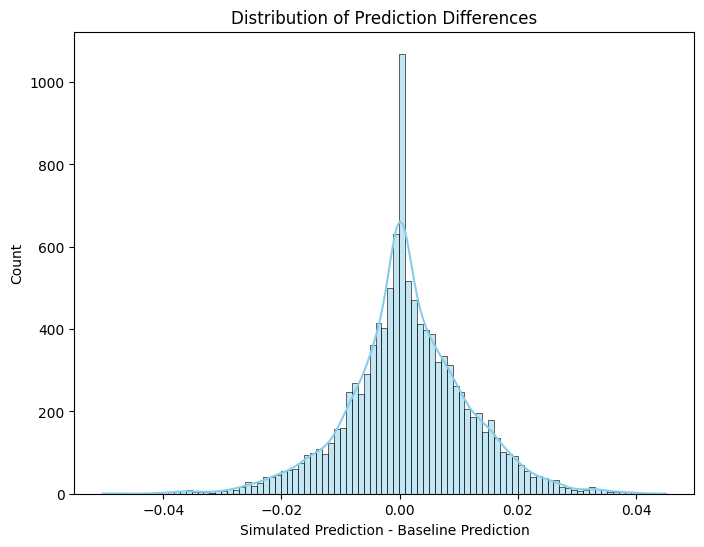

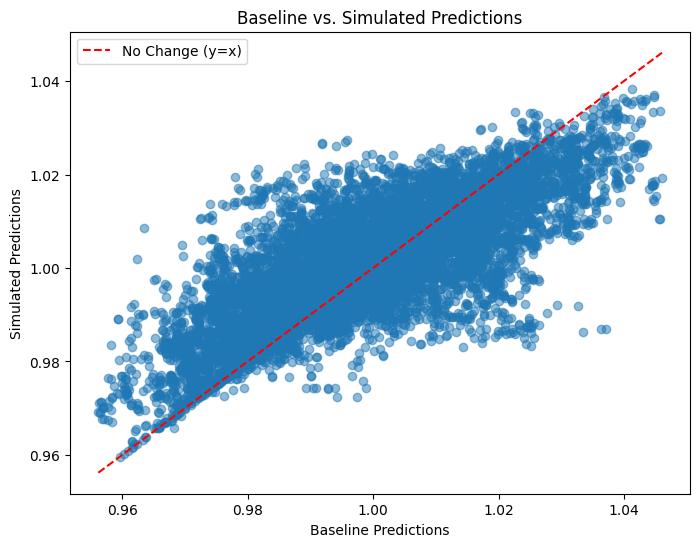

In [198]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute the difference between simulated and baseline predictions
pred_diff = sim_preds - reg_preds

# Plot a histogram of the differences with a kernel density estimate
plt.figure(figsize=(8, 6))
sns.histplot(pred_diff, kde=True, color='skyblue')
plt.xlabel('Simulated Prediction - Baseline Prediction')
plt.title('Distribution of Prediction Differences')
plt.show()

# Create a scatter plot comparing baseline predictions (reg_preds) with simulated predictions (sim_preds)
plt.figure(figsize=(8, 6))
plt.scatter(reg_preds, sim_preds, alpha=0.5)
# Plot a reference line for no change (y = x)
min_pred = min(np.min(reg_preds), np.min(sim_preds))
max_pred = max(np.max(reg_preds), np.max(sim_preds))
plt.plot([min_pred, max_pred], [min_pred, max_pred], color='red', linestyle='--', label='No Change (y=x)')
plt.xlabel('Baseline Predictions')
plt.ylabel('Simulated Predictions')
plt.title('Baseline vs. Simulated Predictions')
plt.legend()
plt.show()
